# Description
Calculation of the number of passes using real breadcrumbs. Finished on May 18th, 2026. It is the first version it can count by boundary cell. The grid is done by rectangles

In [73]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
from locallib.picarrodb import *
from locallib.query import *
from locallib.box import *
from locallib.query import *

import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.geometry import LineString, Point
from shapely.affinity import rotate
import numpy as np
import pandas as pd
import geopandas as gpd
import warnings
from inc import *
from shapely.ops import polygonize, unary_union

# Configuration

In [75]:
tol_deg  = 5
street_length = 10
sampling_distance = 25 
dx = 0.5         # Thickness of each vertical bar
d_angles = -10 * np.ones(len(np.arange(0, 181, 10)))  # 10 degree rotation steps from 0 to 360 inclusive

# Query the surveys

In [76]:
survey = pd.read_pickle("breadcrumbs_for_current_report_area.pkl")
survey_gdf = gpd.GeoDataFrame(survey, geometry = 'geometry')
utm_crs = survey_gdf.estimate_utm_crs()
survey_gdf = survey_gdf.to_crs(utm_crs)

# Algorithm starts here
## Prepare the surveys

In [77]:
# Compute the union of the survey geometries and simplify the result
#survey_union = survey_gdf.unary_union.simplify(10)  # Adjust tolerance 1.0 as needed
survey_union = survey_gdf.unary_union  # Adjust tolerance 1.0 as needed

# Create a GeoDataFrame from the union
survey_union_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union]},
    crs=survey_gdf.crs
)

# Make an offset of 10 (buffer by 10 units)
survey_union_offset_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union.buffer(street_length/2, cap_style=2)]},
    crs=survey_gdf.crs,
    geometry='geometry'
)

In [78]:
# Get the center as the midpoint of the bounds (average of min/max x/y)
minx, miny, maxx, maxy = survey_union_offset_gdf.total_bounds
center = Point((minx + maxx) / 2, (miny + maxy) / 2)
print("Center of the bounds:", center)

# Shift the survey_union_offset_gdf geometry so that the centroid is at (0, 0)
survey_union_offset_gdf['geometry'] = survey_union_offset_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)

Center of the bounds: POINT (586822.3283899999 4131875.581945)


In [79]:
survey_gdf['geometry'] = survey_gdf.geometry.translate(
    xoff=-center.x, yoff=-center.y
)
survey_gdf.set_geometry('geometry', inplace=True)


/tmp/ipykernel_1855279/3853611118.py:4: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


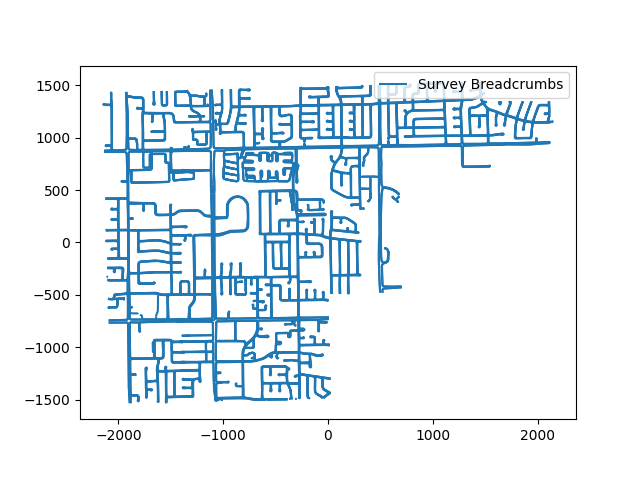

In [80]:
fig,ax = plt.subplots()
survey_gdf.plot(ax=ax, label='Survey Breadcrumbs')
survey_union_offset_gdf.plot(ax=ax, color='red', alpha=0.5, label='Street')
ax.legend()

# Generate the grid

In [81]:
# Assuming 'angle' and 'intersection_gdf' are in scope
def points_and_rotate(bottom, rot_angle):
    # Convert to Point, rotate each, and return as two tuples
    if isinstance(bottom, list) and all(isinstance(pt, tuple) and len(pt) == 2 for pt in bottom):
        rotated = [rotate(Point(pt), angle=rot_angle, origin=(0, 0)) for pt in bottom]
        if len(rotated) == 2:
            return (tuple(rotated[0].coords[0]), tuple(rotated[1].coords[0]))
    return (None, None)



In [82]:
import time
from shapely.geometry import MultiPoint
times = []
def get_max_min_points(df):
   min_x, min_y, max_x, max_y = MultiPoint(list(df['geometry'])).bounds
   return max_y - min_y

def get_nop(df):
    return df.shape[0]

start = time.perf_counter()
output_gdf = gpd.GeoDataFrame()
cumulative = 0
angle = 0
bounds = survey_union_offset_gdf.total_bounds
min_x, min_y, max_x, max_y = map(float, bounds)  # Ensure cast to float
r_x = np.sqrt(max_x**2 + max_y**2)
r_y = np.sqrt(min_x**2 + min_y**2)

# Compute number of columns safely and cast to int
num_cols = int(np.floor((2*r_x) / sampling_distance)) + 1

# Compute bar center x-positions
x_centers = np.linspace(-r_x, r_x, num=num_cols)

# For each center, form a thin rectangle
grid_lines = [
Polygon([
    (x - dx/2, r_y),
    (x + dx/2, r_y),
    (x + dx/2, -r_x),
    (x - dx/2, -r_x)
])
for x in x_centers
]
# Define the vector
vec = np.array([1,0])
ortho_vec = np.array([0,1])
grid_lines_gdf = gpd.GeoDataFrame({'geometry': grid_lines}, crs=survey_gdf.crs, geometry='geometry')
grid_lines_gdf['grid_idx'] = grid_lines_gdf.index
init_time = time.perf_counter()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    current_vec = vec   
    current_ortho_vec = ortho_vec
    for d_angle in d_angles:
            print('Processing angle: ', angle)
            # Rotate the map
            start_rotate = time.perf_counter()
            if angle == 0:
                contour_gdf = survey_union_offset_gdf.copy()
                survey_rotated_gdf = survey_gdf.copy()
            else:
                contour_gdf['geometry'] = contour_gdf['geometry'].rotate(angle=-d_angle, origin=(0,0))
                survey_rotated_gdf['geometry'] = survey_rotated_gdf['geometry'].rotate(angle=-d_angle, origin=(0,0))

            end_rotate = time.perf_counter()
            print(f'Time to Grid rotation: {end_rotate - start_rotate}')
            times.append({  
                'angle': angle,
                'Grid rotation': end_rotate - start_rotate
            })
            #Create the intersection of the grid with the survey offset
            intersection_gdf = gpd.overlay(
                grid_lines_gdf, 
                contour_gdf, 
                how='intersection', 
                keep_geom_type=False
            )    
            
            intersection_gdf = intersection_gdf.explode(index_parts=True)
            intersection_gdf.reset_index(drop=True, inplace=True)
            intersection_gdf.set_geometry('geometry', inplace=True)
            intersection_gdf.to_crs(survey_gdf.crs, inplace=True)
            end_intersection = time.perf_counter()
            print(f'Time to Grid intersection: {end_intersection - end_rotate}')

            start_bottom = time.perf_counter()
            intersection_gdf['bottom_points'] = intersection_gdf['geometry'].apply(lambda geom: get_bottom_two_points(geom,angle,rotattion = False))

            # Get the unit vector along the [1,0] direction or the rotated version
            intersection_gdf['unit_vector'] = intersection_gdf['bottom_points'].apply(safe_unit_vector)

            # Get teh angle between the unit vector and the rotated vector
            intersection_gdf['angle_measured'] = intersection_gdf['unit_vector'].apply(lambda vec: angle_between_vectors(vec,rotated_vec=[1,0]))
            intersection_gdf['angle_rotated'] = angle
            end_angle = time.perf_counter()
            print(f'Time to Angle Measurement: {end_angle - start_bottom}')
            end_angle = time.perf_counter()
            print(f'Time to Angle Measurement: {end_angle - start_bottom}')
            times.append({  
                'angle': angle,
                'Angle Measurement': end_angle - start_bottom
            })

            start_right_angles = time.perf_counter()
            # Get only those lines which are aligned with the rotated vector
            right_angles = intersection_gdf[np.isclose(intersection_gdf['angle_measured'], 0, atol=tol_deg)]

            right_angles['cell_boundary'] = right_angles.apply(lambda row: get_central_line_vertical(row), axis=1)
            right_angles['cell_boundary_length'] = right_angles['cell_boundary'].apply(lambda line: line.length) - 1
            #mean_cell_boundary_length = right_angles['cell_boundary_length'].mean()
            #std_cell_boundary_length = right_angles['cell_boundary_length'].std()
            #right_angles = right_angles[np.isclose(right_angles['cell_boundary_length'], 12.7, atol=2*.9)]
            right_angles['grid_boundary'] = right_angles['geometry']
            right_angles['geometry'] = right_angles['cell_boundary']
            right_angles = right_angles.set_geometry('geometry')
            right_angles = right_angles.set_crs(utm_crs)
            right_angles['cell_idx'] = right_angles.index
            end_right_angles = time.perf_counter()
            print(f'Time to get the right angles: {end_right_angles - end_angle}')
            times.append({  
                'angle': angle,
                'Right Angles': end_right_angles - end_angle
            })


            start_survey_intersection = time.perf_counter()
            #Intersection of the boundaries with the surveys
            intersection_survey_gdf = gpd.overlay(right_angles, survey_rotated_gdf[['Order','geometry']], how='intersection', keep_geom_type=False)
            intersection_survey_gdf = intersection_survey_gdf.explode(index_parts=True)
            intersection_survey_gdf = intersection_survey_gdf[['Order','geometry']]

            intersection_survey_gdf = intersection_survey_gdf.reset_index(drop=True)
            intersection_survey_gdf = intersection_survey_gdf.set_geometry('geometry')
            intersection_survey_gdf = intersection_survey_gdf.set_crs(utm_crs)
            stop_survey_intersection = time.perf_counter()
            print(f'Time to survey intersection: {stop_survey_intersection - start_survey_intersection}')
            times.append({  
                'angle': angle,
                'Survey Intersection': stop_survey_intersection - start_survey_intersection
            })

            #Join the boundaries with the surveys intersection
            start_join = time.perf_counter()
            r = right_angles.copy()
            r['geometry'] = r['cell_boundary']
            r.drop(columns = ['cell_boundary','grid_boundary'], inplace=True)
            r = r.set_geometry('geometry')
            r = r.set_crs(utm_crs)
            joined = gpd.sjoin(r, intersection_survey_gdf, how='right', predicate='intersects')

            spread = joined.groupby('cell_idx').apply(lambda x: get_max_min_points(x))
            nop = joined.groupby('cell_idx').apply(lambda x: get_nop(x))
            spread_df = spread.reset_index()
            spread_df.rename(columns = {0:'spread'}, inplace=True)
            nop_df = nop.reset_index()
            nop_df.rename(columns = {0:'nop'}, inplace=True)
            result = pd.merge(spread_df, nop_df, on = 'cell_idx', how = 'left')
            r = pd.merge(r, result, on = 'cell_idx', how = 'left')
            stop_join = time.perf_counter()
            print(f'Time to nop and spread: {stop_join - start_join}')
            times.append({  
                'angle': angle,
                'Nop and Spread': stop_join - start_join
            })

            #filtered = right_angles[(right_angles['cell_boundary_length'] < 2*street_length)]
            output_gdf = pd.concat([output_gdf, r])
        
            #output_gdf = output_gdf[(output_gdf['spread'] < street_length + 3*std_spread) & (output_gdf['cell_boundary_length'] < street_length + 3*std_len)]
            angle = angle + d_angle
output_gdf.drop(columns = ['cell_idx'], inplace = True)


Processing angle:  0
Time to Grid rotation: 0.004175901995040476
Time to Grid intersection: 0.6850357309449464
Time to Angle Measurement: 0.33536376303527504
Time to Angle Measurement: 0.33546631096396595
Time to get the right angles: 0.950588645064272
Time to survey intersection: 0.14570188708603382
Time to nop and spread: 3.409403327968903
Processing angle:  -10.0
Time to Grid rotation: 0.15389273699838668
Time to Grid intersection: 0.6705739779863507
Time to Angle Measurement: 0.39158978301566094
Time to Angle Measurement: 0.39168683893512934
Time to get the right angles: 0.13759392907377332
Time to survey intersection: 0.06748219800647348
Time to nop and spread: 0.5425076179672033
Processing angle:  -20.0
Time to Grid rotation: 0.19942174199968576
Time to Grid intersection: 1.0369715159758925
Time to Angle Measurement: 0.513522375957109
Time to Angle Measurement: 0.5136193969519809
Time to get the right angles: 0.06519488710910082
Time to survey intersection: 0.05800845904741436
Ti

In [83]:
time_df = pd.DataFrame(times)
time_df.groupby('angle').agg({'Grid rotation':'first', 'Angle Measurement':'first', 'Right Angles':'first', 'Survey Intersection':'first', 'Nop and Spread':'first'}).reset_index()
time_df.describe()

,angle,Grid rotation,Angle Measurement,Right Angles,Survey Intersection,Nop and Spread
count,95.000000,19.000000,19.000000,19.000000,19.000000,19.000000
mean,-90.000000,0.175552,0.454282,0.208608,0.069563,0.763776
std,55.062827,0.053126,0.128951,0.349912,0.044584,1.287997
min,-180.000000,0.004176,0.330520,0.027288,0.039666,0.099698
25%,-140.000000,0.162714,0.387977,0.046741,0.045126,0.145522
50%,-90.000000,0.173895,0.417350,0.059201,0.051583,0.228943
75%,-40.000000,0.195448,0.462558,0.087034,0.062745,0.320900
max,0.000000,0.288079,0.902045,1.069118,0.192464,3.856034


In [84]:
# Filter the points

output_gdf['diff'] = (output_gdf['cell_boundary_length'] - output_gdf['spread'])/street_length
print(output_gdf.shape[0])
output_gdf_no_nan_spread = output_gdf[~output_gdf['nop'].isna()]
print(output_gdf_no_nan_spread.shape[0])
output_gdf_short = output_gdf_no_nan_spread.copy()
#output_gdf_short = output_gdf_no_nan_spread[output_gdf_no_nan_spread['cell_boundary_length'] < 2*street_length]
print(output_gdf_short.shape[0])
output_gdf_long = output_gdf_short[(output_gdf_short['diff'] >= 1) & (output_gdf_short['diff'] < 1.1)]
print(len(output_gdf_long))


5827
5781
5781
5287


In [85]:
#Rotate to the original value

from shapely.affinity import rotate

# Rotate all geometries "in one go" using vectorized .apply on the DataFrame
# Note: negative sign, since original was rotate to -angle_rotated
rotated_output_gdf = output_gdf_long.copy()
rotated_output_gdf['geometry'] = [
    rotate(geom, angle, origin=(0, 0))
    for geom, angle in zip(rotated_output_gdf['geometry'].values, rotated_output_gdf['angle_rotated'].values)
]

In [86]:
#Remove all the overlaps by taking:
#1. The cell with the most intersections
#2. The cell with the largest boundary length if there is a tie

overlapped = gpd.sjoin(rotated_output_gdf, rotated_output_gdf, how = 'inner', predicate = 'intersects')
overlapped = overlapped[overlapped.index != overlapped.index_right].copy()
overlapped = overlapped.reset_index()

overlapped = overlapped[['index','index_right','cell_boundary_length_left']]
indx_to_remove = []

while (len(overlapped) > 0):
    overlapped_summary = overlapped.groupby('index').agg({'cell_boundary_length_left':'mean','index_right':'nunique'}).sort_values(by = 'index_right', ascending = False)
    idx_intersection = overlapped_summary['index_right'].idxmax()
    max_intersections = overlapped_summary['index_right'].max()
    if max_intersections == 1:
        idx_remove = overlapped_summary['cell_boundary_length_left'].idxmax()
        max_remove = overlapped_summary['cell_boundary_length_left'].max()
    else:
        idx_remove = idx_intersection
        max_remove = max_intersections
    overlapped = overlapped[overlapped['index'] != idx_remove]
    overlapped = overlapped[overlapped['index_right'] != idx_remove]
    indx_to_remove.append(idx_remove)
removed_gdf = rotated_output_gdf[~(rotated_output_gdf.index.isin(indx_to_remove))]


In [87]:
#Create the cells

geom = survey_union_offset_gdf.iloc[0].geometry

# Direct extraction of geometry numpy array is typically faster than itertuples or apply
lines = removed_gdf.geometry.values
splitters = unary_union(lines)

# Only unary_union geom.boundary once and directly pass as list with splitters
network = unary_union([geom.boundary, splitters])

# Polygonize all at once, and filter efficiently using vectorized contains (if available)
cell_polys_gen = list(polygonize(network))
# Use shapely's prepared geometries for faster contains checks
from shapely.prepared import prep
prep_geom = prep(geom)
cell_polys = [poly for poly in cell_polys_gen if prep_geom.contains(poly.representative_point())]

print(f"{len(lines)} splitters -> {len(cell_polys)} cells")
cell_gdf = gpd.GeoDataFrame({'geometry': cell_polys}, crs=survey_union_offset_gdf.crs)

3604 splitters -> 3420 cells


In [88]:
nodes = cell_gdf[['geometry']].copy()
nodes['centroid'] = nodes['geometry'].centroid
nodes.reset_index(inplace=True)

In [89]:
#Create the network
cell_buffer = cell_gdf.copy()
cell_buffer['geometry'] = cell_buffer['geometry'].buffer(0.5, cap_style=2)

#Check for rook contiguity
edges_gdf = gpd.sjoin(cell_buffer, cell_buffer, how = 'left', predicate = 'intersects')
edges_gdf.rename(columns = {'index_right':'v'}, inplace = True)
edges_gdf['u'] = edges_gdf.index
edges_gdf = edges_gdf[edges_gdf['u'] < edges_gdf['v']][['geometry', 'u', 'v']]
edges_wnop_gdf = gpd.sjoin(edges_gdf, removed_gdf, how = 'left', predicate = 'intersects')

import networkx as nx

# Create a networkx graph
G = nx.Graph()

# Add nodes for each cell (node ids from 'u' and 'v' columns)
for idx,row in nodes.iterrows():
    G.add_node(idx)
    G.nodes[idx]['centroid'] = row['centroid']

# Add edges between neighboring cells
for _, row in edges_wnop_gdf.iterrows():
    u = row['u']
    v = row['v']
    G.add_edge(u, v)
    G[u][v]['numberOfIntersection'] = row['nop']
# Optionally display basic info about the network
print(f"Created network with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Created network with 3420 nodes and 4135 edges.


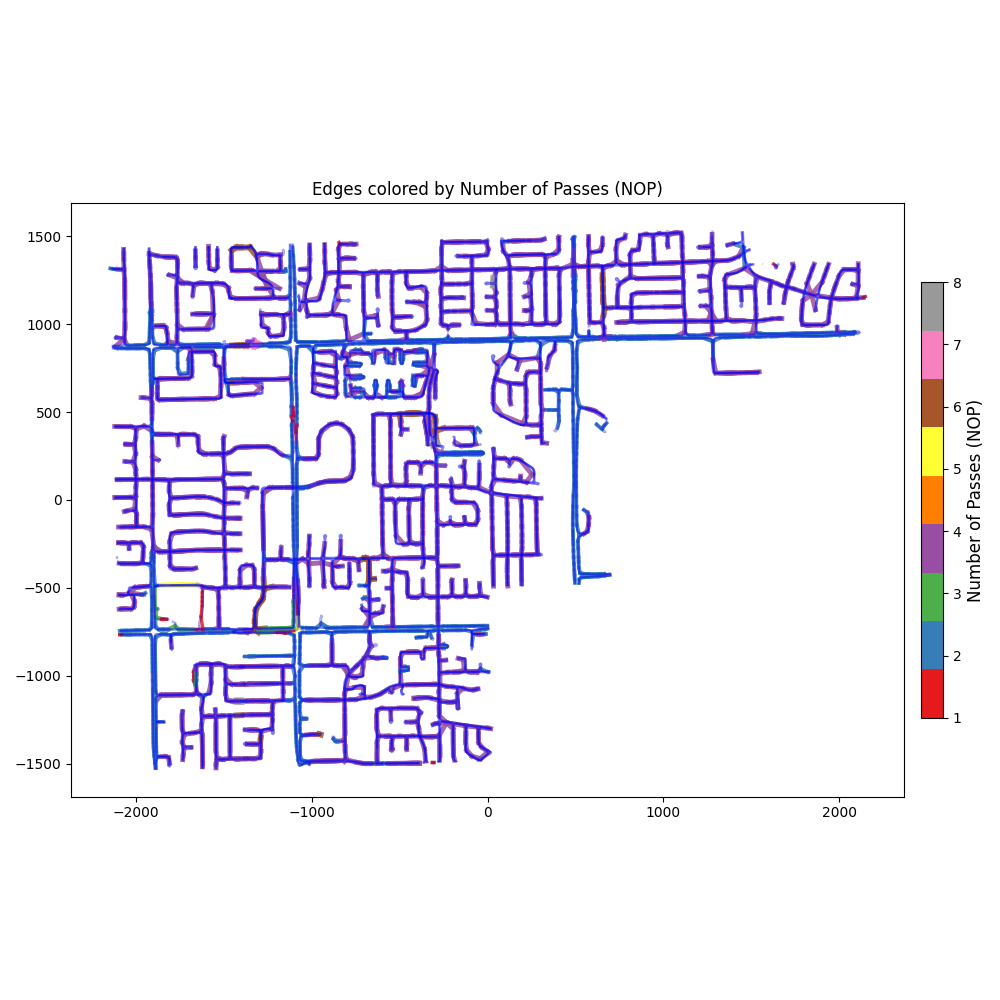

In [90]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the cells for reference/background (optional)
if 'geometry' in cell_gdf.columns:
    cell_gdf.boundary.plot(ax=ax, color='lightgray', linewidth=0.5, alpha=0.7)

# Gather all 'distance' attributes to scale line thickness
edge_distances = [G[u][v].get('distance', 1) for u, v in G.edges()]
max_dist = max(edge_distances) if edge_distances else 1

# Gather all 'numberOfIntersection' to use for line colormap/width
all_nop = [G[u][v].get('numberOfIntersection', 0) for u, v in G.edges()]
max_nop = max(all_nop) if all_nop else 1

# Use a colormap to represent number of passes (nop)
norm = plt.Normalize(vmin=min(all_nop) if all_nop else 0, vmax=max_nop)
cmap = cm.Set1

for u, v in G.edges():
    if 'centroid' in G.nodes[u] and 'centroid' in G.nodes[v]:
        p1 = G.nodes[u]['centroid']
        p2 = G.nodes[v]['centroid']
        # Extract x,y
        x_vals = [p1.x, p2.x]
        y_vals = [p1.y, p2.y]
        nop = G[u][v].get('numberOfIntersection', 0)
        color = cmap(norm(nop))
        linewidth = 2 + 3*(nop / max_nop) if max_nop > 0 else 2
        
        ax.plot(x_vals, y_vals, color=color, linewidth=linewidth, alpha=0.85)
survey_gdf.plot(ax = ax, color = 'blue', alpha = 0.3)

# Create a colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Number of Passes (NOP)', fontsize=12)

ax.set_aspect('equal')
ax.set_title('Edges colored by Number of Passes (NOP)')
plt.tight_layout()
plt.show()